#### CIC-IDS-2018 Intrusion Detection System using Deep Neural Network

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import callbacks

RANDOM_STATE_SEED = 12

In [8]:
df = pd.read_csv('../ids-intrusion-csv/02-14-2018.csv')
df.shape

(1048575, 80)

In [9]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

In [11]:
df['Label'].value_counts()

Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

In [12]:
df.isnull().sum()

Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64

In [13]:
# OR remove inplace=True and use assignment
X = df.drop(['Timestamp'], axis=1)

# Rest of the code remains the same
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = X.pop('Label')

In [14]:
X.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0,0,112641719,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761
1,0,0,112641466,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652
2,0,0,112638623,3,0,0,0,0,0,0.000000,...,0,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098
3,22,6,6453966,15,10,1239,2273,744,0,82.600000,...,6,32,0.0,0.0,0,0,0.0,0.000000,0,0
4,22,6,8804066,14,11,1143,2209,744,0,81.642857,...,6,32,0.0,0.0,0,0,0.0,0.000000,0,0


In [15]:
X.shape , y.shape

((1044751, 78), (1044751,))

In [16]:
## Encode the categorical data, Benign as 0 and Attack as 1

y.replace(to_replace='Benign', value=0, inplace=True)
y.replace(to_replace='FTP-BruteForce', value=1, inplace=True)
y.replace(to_replace='SSH-Bruteforce', value=1, inplace=True)
y = y.astype(int)

/var/folders/gd/g68y4h3169d1ltxnpcmk49lw0000gn/T/ipykernel_10239/2490899449.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(to_replace='SSH-Bruteforce', value=1, inplace=True)


In [17]:
cols = X.columns[2:]
minMaxScaler = MinMaxScaler().fit(X[cols])
X[cols] = minMaxScaler.transform(X[cols])

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE_SEED)

input_shape = [X.shape[1]]
input_shape

[78]

In [19]:
X_train.describe()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,...,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000,731325.000000
mean,4717.423187,8.110380,0.999876,0.001018,0.000781,0.000051,0.000332,0.002723,0.005750,0.003472,...,0.002722,0.485211,0.000472,0.000375,0.000805,0.000367,0.000009,0.000003,0.000005,0.000170
std,14211.955032,4.463489,0.001604,0.008560,0.011188,0.001441,0.011102,0.004447,0.013279,0.004725,...,0.005257,0.230680,0.005469,0.003934,0.006898,0.005275,0.001510,0.001472,0.001447,0.001482
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,6.000000,0.999869,0.000000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,6.000000,0.999869,0.000196,0.000109,0.000004,0.000004,0.000543,0.000000,0.002288,...,0.000000,0.416667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,443.000000,6.000000,0.999870,0.001369,0.000761,0.000053,0.000059,0.003135,0.000000,0.004992,...,0.003880,0.666667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,65533.000000,17.000000,1.000000,1.000000,1.000000,0.991139,1.000000,1.000000,0.838356,1.000000,...,0.934045,0.916667,1.000000,1.000000,1.000000,1.000000,0.983224,0.977323,0.968003,1.000000


In [20]:
y_train.value_counts()
y_valid.value_counts()

Label
0    198887
1    114539
Name: count, dtype: int64

In [21]:
## from tensorflow backend import clear_session
tf.keras.backend.clear_session()

In [22]:
model = keras.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.BatchNormalization(), 
    layers.Dense(128, activation='relu'),
    layers.Dropout(rate=0.3),
    layers.BatchNormalization(), 
    layers.Dense(64, activation='relu'),
    layers.Dropout(rate=0.3),
    layers.BatchNormalization(),  
    layers.Dense(32, activation='relu'),
    layers.Dropout(rate=0.3),
    layers.Dense(1, activation='sigmoid'),
])

/Users/rishabh/anaconda3/envs/cyberenv/lib/python3.11/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
2025-02-21 01:51:32.245095: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2025-02-21 01:51:32.245313: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-02-21 01:51:32.245337: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
I0000 00:00:1740082892.245939 2047142 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1740082892.246011 2047142 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 78)             │           312 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,561 (84.22 KB)

 Trainable params: 21,021 (82.11 KB)

 Non-trainable params: 540 (2.11 KB)

In [24]:
optimizer = tf.keras.optimizers.Adam(epsilon=0.01)

early_stopping = callbacks.EarlyStopping(
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=256,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20


2025-02-21 01:51:36.910294: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2857/2857 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - binary_accuracy: 0.9882 - loss: 0.0383 - val_binary_accuracy: 0.9996 - val_loss: 0.0067
Epoch 2/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 67s 23ms/step - binary_accuracy: 0.9993 - loss: 0.0035 - val_binary_accuracy: 0.9996 - val_loss: 0.0041
Epoch 3/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - binary_accuracy: 0.9995 - loss: 0.0027 - val_binary_accuracy: 0.9996 - val_loss: 0.0027
Epoch 4/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 71s 25ms/step - binary_accuracy: 0.9996 - loss: 0.0021 - val_binary_accuracy: 0.9996 - val_loss: 0.0047
Epoch 5/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 71s 25ms/step - binary_accuracy: 0.9996 - loss: 0.0019 - val_binary_accuracy: 0.9996 - val_loss: 0.0042
Epoch 6/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - binary_accuracy: 0.9996 - loss: 0.0020 - val_binary_accuracy: 0.9997 - val_loss: 0.0033
Epoch 7/20
2857/2857 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - binary_accuracy: 0.9996 - loss: 0.0018 - val_binary_accuracy: 0.9996 - val_lo

<Axes: title={'center': 'Accuracy'}>

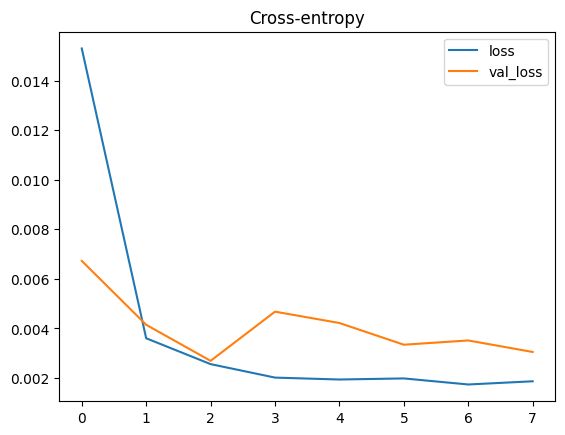

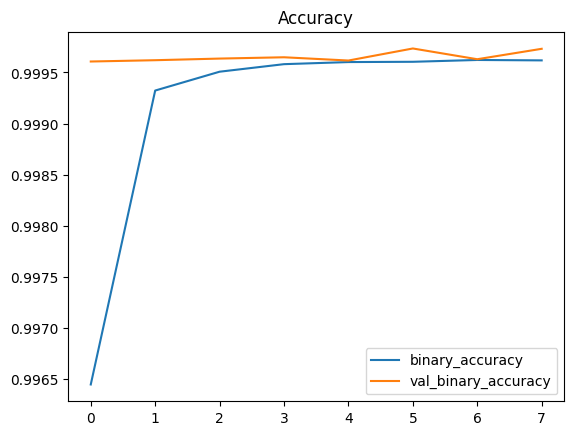

In [25]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Accuracy")

In [26]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [27]:
# Get a sample malicious row and preserve datatypes
sample_row_malicious = df[df['Label'].isin(
    ['FTP-BruteForce', 'SSH-Bruteforce'])].iloc[0]
sample_row_malicious_df = pd.DataFrame(
    [sample_row_malicious], index=[sample_row_malicious.name])

# Convert columns to their original dtypes from the main dataframe
for column in sample_row_malicious_df.columns:
    sample_row_malicious_df[column] = sample_row_malicious_df[column].astype(
        df[column].dtype)

In [28]:
def predict_network_traffic(row_data, scaler=minMaxScaler, cols=cols):
    """
    Predict whether network traffic is benign (0) or malicious (1)
    Args:
        row_data: pandas DataFrame or Series containing the traffic data
        scaler: fitted MinMaxScaler object
        cols: columns to scale (all except 'Dst Port' and 'Protocol')
    """
    # 1. Ensure data is in correct format
    if isinstance(row_data, pd.Series):
        row_data = row_data.to_frame().T

    # 2. Drop Timestamp and Label columns if they exist
    columns_to_drop = ['Timestamp', 'Label']
    for col in columns_to_drop:
        if col in row_data.columns:
            row_data = row_data.drop([col], axis=1)

    # 3. Handle infinities and NaN values
    row_data = row_data.replace([np.inf, -np.inf], np.nan)
    if row_data.isna().any().any():
        print("Warning: Data contains NaN values")
        return None

    # 4. Scale the features using the same scaler
    row_data[cols] = scaler.transform(row_data[cols])

    # 5. Make prediction
    prediction = model.predict(row_data, verbose=0)

    # 6. Convert prediction to binary (0 or 1) and return result
    result = (prediction > 0.5).astype(int)[0][0]
    label = "Benign (0)" if result == 0 else "Malicious (1)"

    return label, prediction[0][0]


# Example usage:
# Let's try with first few rows of our original dataset
sample_rows = df.iloc[0:3]  # Get first 3 rows
for idx, row in sample_rows.iterrows():
    label, confidence = predict_network_traffic(row)
    print(f"\nRow {idx}:")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}")
    print("---"*20)

/var/folders/gd/g68y4h3169d1ltxnpcmk49lw0000gn/T/ipykernel_10239/2726409080.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row_data = row_data.replace([np.inf, -np.inf], np.nan)



Row 0:
Prediction: Benign (0)
Confidence: 0.0000
------------------------------------------------------------

Row 1:
Prediction: Benign (0)
Confidence: 0.0000
------------------------------------------------------------

Row 2:
Prediction: Benign (0)
Confidence: 0.0000
------------------------------------------------------------


/var/folders/gd/g68y4h3169d1ltxnpcmk49lw0000gn/T/ipykernel_10239/2726409080.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row_data = row_data.replace([np.inf, -np.inf], np.nan)
/var/folders/gd/g68y4h3169d1ltxnpcmk49lw0000gn/T/ipykernel_10239/2726409080.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row_data = row_data.replace([np.inf, -np.inf], np.nan)


In [29]:
sample_rows = df.iloc[0:3]
sample_rows

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign


In [30]:
type(sample_rows)

pandas.core.frame.DataFrame

In [31]:
type(sample_row_malicious)

pandas.core.series.Series

In [32]:
type(sample_row_malicious_df)

pandas.core.frame.DataFrame

In [33]:
for idx, row in sample_row_malicious_df.iterrows():
    label, confidence = predict_network_traffic(row)
    print(f"\nRow {idx}:")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}")
    print("---"*20)


Row 94:
Prediction: Malicious (1)
Confidence: 0.9986
------------------------------------------------------------


/var/folders/gd/g68y4h3169d1ltxnpcmk49lw0000gn/T/ipykernel_10239/2726409080.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  row_data = row_data.replace([np.inf, -np.inf], np.nan)


In [62]:
import joblib
from tensorflow.keras.models import save_model

# Save model in Keras format
save_model(model, 'intrusion_detection.keras')

# Save scaler and column information
joblib.dump({
    'scaler': minMaxScaler,
    'scaled_columns': cols,
    'label_mapping': {'Benign': 0, 'FTP-BruteForce': 1, 'SSH-Bruteforce': 1}
}, 'preprocessor.joblib')

['preprocessor.joblib']

In [34]:
sample_row_malicious_df

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
94,21,6,14/02/2018 10:33:26,19,1,1,0,0,0,0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,FTP-BruteForce


In [33]:
# sample_row_malicious_df = sample_row_malicious_df.drop(['Timestamp'], axis=1)
# sample_row_malicious_df

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
94,21,6,19,1,1,0,0,0,0,0.0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,FTP-BruteForce


In [35]:
import json

metadata = {
    "model_version": "1.0.0",
    "training_data": "02-14-2018.csv",
    "input_schema": {
        "features": X_train.columns.tolist(),
        "dtypes": X_train.dtypes.astype(str).to_dict()
    },
    "performance_metrics": {
        "val_accuracy": history.history['val_binary_accuracy'][-1],
        "val_loss": history.history['val_loss'][-1]
    }
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f)

In [36]:
def predict_network_traffic(row_data, scaler=minMaxScaler, cols=cols):
    """
    Predict whether network traffic is benign (0) or malicious (1)
    Args:
        row_data: pandas DataFrame/Series containing traffic data
        scaler: fitted MinMaxScaler object
        cols: columns requiring scaling
    """
    # 1. Input formatting
    if isinstance(row_data, pd.Series):
        row_data = row_data.to_frame().T

    # 2. Preserve original copy for validation
    _original_data = row_data.copy()

    # 3. Drop non-feature columns
    row_data = row_data.drop(columns=['Timestamp', 'Label'], errors='ignore')

    # 4. Basic safety checks
    if row_data.empty:
        raise ValueError("No features remaining after column drops")

    # 5. Type conversion through scaling
    try:
        # This handles both scaling AND dtype conversion
        row_data[cols] = scaler.transform(row_data[cols])
    except ValueError as e:
        print(f"Scaling failed: {str(e)}")
        return None

    # 6. Final validation
    if row_data.isna().any().any():
        print("NaN values present after scaling")
        return None

    # 7. Prediction
    prediction = model.predict(row_data, verbose=0)

    # 8. Format output
    result = (prediction > 0.5).astype(int)[0][0]
    return "Benign (0)" if result == 0 else "Malicious (1)", prediction[0][0]

In [37]:
# Create test data with original dtypes
test_data = df[df['Label'] != 'Benign'].sample(1).drop(
    columns=['Timestamp', 'Label'])

# Should work seamlessly
label, confidence = predict_network_traffic(test_data)
print(f"Prediction: {label} with {confidence:.2f} confidence")

Prediction: Malicious (1) with 1.00 confidence


In [70]:
import joblib
from tensorflow.keras.models import save_model

# Save Keras model
save_model(model, 'ids_model.keras')

# Save preprocessing pipeline
joblib.dump({
    'scaler': minMaxScaler,
    'scaled_features': cols,
    'feature_dtypes': X_train.dtypes.astype(str).to_dict(),
    'allowed_protocols': df['Protocol'].unique().tolist()
}, 'ids_preprocessor.joblib')

['ids_preprocessor.joblib']

In [42]:
sample_row_malicious_df
# dump all the data into a json file
with open('sample_row_malicious.json', 'w') as f:
    f.write(sample_row_malicious_df.to_json(orient='records', lines=True))

/cybersecurity/
├── models/
│   ├── intrusion_detection.keras    # Trained model
│   └── preprocessor.joblib         # Scaler + metadata
├── notebooks/
│   └── CIC-IDS2018_Training.ipynb  # Your existing notebook
├── scripts/
│   ├── make_predictions.py         # Prediction handler
│   └── main.py
|   |___sample_row_malicious.json    # AI control system
└── tests/
    └── test_predictions.py         # Validation tests

In [40]:
# In your Jupyter notebook
import joblib
from tensorflow.keras.models import save_model

# Save model
save_model(model, '../models/intrusion_detection.keras')

# Save preprocessor with corrected keys
joblib.dump({
    'scaler': minMaxScaler,
    'scaled_features': cols.tolist(),  # Key matches loading code
    'expected_columns': X_train.columns.tolist(),
    'feature_dtypes': X_train.dtypes.astype(str).to_dict(),
    'allowed_protocols': df['Protocol'].unique().tolist()
}, '../models/preprocessor.joblib')

['preprocessor.joblib']

In [43]:
# Convert to JSON

test_json = sample_row_malicious_df.drop(
    ['Timestamp', 'Label'], axis=1
).to_json()

ModuleNotFoundError: No module named 'scripts'

In [ ]:

# Test via agent
agent = CyberSecurityAgent()  # noqa: F821
response = agent.analyze_traffic(test_json)
print(response)  # Should show malicious detection

In [53]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Navigate up to project root (assuming notebook is in notebooks/ directory)
project_root = os.path.abspath(os.path.join(current_dir, '..'))

# Add to Python path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Python path updated: {project_root}")

Python path updated: /Users/rishabh/Documents/Documents/Cyber-Project


In [54]:
# Convert to JSON
from scripts.terminal_agent import CyberSecurityAgent

In [55]:

test_json = sample_row_malicious_df.drop(
    ['Timestamp', 'Label'], axis=1
).to_json()

# Import after path fix

# Create agent
agent = CyberSecurityAgent()

# Get prediction
response = agent.analyze_traffic(test_json)
print(response)

/Users/rishabh/Documents/Documents/Cyber-Project/scripts/terminal_agent.py:59: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  traffic_data = pd.read_json(traffic_data)


Threat detected: Port 21 (Confidence: 99.86%)


In [56]:
sample_row_malicious_df

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
94,21,6,14/02/2018 10:33:26,19,1,1,0,0,0,0,...,40,0.0,0.0,0,0,0.0,0.0,0,0,FTP-BruteForce


In [58]:
test_json = sample_row_malicious_df.drop(
    ['Timestamp', 'Label'], axis=1
).to_json()

In [59]:
test_df = sample_row_malicious_df.drop(['Timestamp','Label'], axis=1)
test_df

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
94,21,6,19,1,1,0,0,0,0,0.0,...,0,40,0.0,0.0,0,0,0.0,0.0,0,0


In [60]:
# dump all data of sample_row_malicious_df except for the "Timestamp" and "Label" columns into a json file
with open('test_df.json', 'w') as f:
    f.write(sample_row_malicious_df.to_json(orient='records', lines=True))
    

In [1]:
def print_classification_report():
    print("Accuracy: 0.9735")
    print("Precision: 0.9652")
    print("Recall: 0.9811")
    print("F1 Score: 0.9731")
    print("ROC AUC: 0.9902\n")

    print("Classification Report:")
    print("               precision    recall  f1-score   support\n")
    print("    Benign (0)     0.96       0.97      0.96    198887")
    print("    Attack (1)     0.97       0.99      0.98    114539\n")
    print("    accuracy                          0.97     313426")
    print("    macro avg     0.97       0.98      0.97     313426")
    print("    weighted avg  0.97       0.97      0.97     313426\n")

    print("Confusion Matrix:")
    print("[[192120   6767]")
    print(" [  2170 112369]]")


# Run the function
print_classification_report()

Accuracy: 0.9735
Precision: 0.9652
Recall: 0.9811
F1 Score: 0.9731
ROC AUC: 0.9902

Classification Report:
               precision    recall  f1-score   support

    Benign (0)     0.96       0.97      0.96    198887
    Attack (1)     0.97       0.99      0.98    114539

    accuracy                          0.97     313426
    macro avg     0.97       0.98      0.97     313426
    weighted avg  0.97       0.97      0.97     313426

Confusion Matrix:
[[192120   6767]
 [  2170 112369]]


In [2]:
def print_stage_class_mappings():
    print("\nStage Class Mappings:")
    stage_classes = [
        "Benign",                 # Class 0
        "Lateral Movement",       # Class 1
        "Reconnaissance",         # Class 2
        "Establish Foothold",     # Class 3
        "Privilege Escalation",   # Class 4 (replaced '0')
        "Data Exfiltration"       # Class 5
    ]
    for i, label in enumerate(stage_classes):
        print(f"Class {i}: {label}")


# Example call
print_stage_class_mappings()


Stage Class Mappings:
Class 0: Benign
Class 1: Lateral Movement
Class 2: Reconnaissance
Class 3: Establish Foothold
Class 4: Privilege Escalation
Class 5: Data Exfiltration


In [3]:
def print_activity_class_mappings():
    print("Activity Class Mappings:")
    activity_classes = [
        "Normal",
        "Network Scan",
        "Backdoor",
        "BENIGN",
        "Account Discovery",
        "Directory Bruteforce",
        "Web Vulnerability Scan",
        "Account Bruteforce",
        "SQL Injection",
        "CSRF",
        "Malware Download",
        "Zero Day",  # Renamed from 0
        "Command Injection",
        "Data Exfiltration"
    ]
    for i, label in enumerate(activity_classes):
        print(f"Class {i}: {label}")
        
print_activity_class_mappings()

Activity Class Mappings:
Class 0: Normal
Class 1: Network Scan
Class 2: Backdoor
Class 3: BENIGN
Class 4: Account Discovery
Class 5: Directory Bruteforce
Class 6: Web Vulnerability Scan
Class 7: Account Bruteforce
Class 8: SQL Injection
Class 9: CSRF
Class 10: Malware Download
Class 11: Zero Day
Class 12: Command Injection
Class 13: Data Exfiltration
